In [1]:
import random
import math
import sys

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from statistics import mean
from functools import reduce
from itertools import combinations
from copy import deepcopy
from scipy.optimize import minimize

Consts and Setup

In [2]:
eps = 1.0e-14
N = 4
M = 10
seed = 42

In [3]:
random.seed(seed)
sns.set_theme(style="whitegrid")

The Heart of Darkness

In [4]:
class DifferentialEvolution:
    def __init__(self,
                 objective_function,
                 constraint_functions,
                 upper_bounds,
                 lower_bounds,
                 population_size):
        self.objective_function = objective_function
        self.constraint_functions = constraint_functions
        self.upper_bounds = upper_bounds
        self.lower_bounds = lower_bounds
        self.population_size = population_size

    def run(self,
            stopping_condition,
            crossover,
            selection_mutation):
        self.initialize_stats()

        population = [[self.new_chromosome(upper, lower) for upper, lower in zip(self.upper_bounds, self.lower_bounds)] for _ in range(self.population_size)]
        scores = [self.evaluate(x) for x in population]
        self.update_stats(population, scores)

        while stopping_condition.check(self):
            new_generation = []
            new_scores = []

            for x, s in zip(population, scores):
                u = crossover.do(x)
                v = selection_mutation.do(x,
                                          population,
                                          self.best_solution_hist[-1],
                                          u)
                v = self.enforce_bounds(v)
                f = self.evaluate(v)

                if f < s:
                    new_generation.append(v)
                    new_scores.append(f)
                else:
                    new_generation.append(x)
                    new_scores.append(s)

            population = new_generation
            scores = new_scores
            self.iter_count += 1
            self.update_stats(population, scores)
        
        return self

    def initialize_stats(self):
        self.iter_count = 0
        self.eval_count = 0
        self.best_solution_hist = []
        self.best_score_hist = []
        self.population_diversity_hist = []

    def update_stats(self, population, scores):
        best_idx = scores.index(min(scores))

        self.best_solution_hist.append(population[best_idx])
        self.best_score_hist.append(scores[best_idx])
        self.population_diversity_hist.append(self.diversity(population))

    def new_chromosome(self, upper, lower):
        return random.uniform(lower, upper)
    
    def enforce_bounds(self, x):
        return [a if lower<=a and a<=upper else self.new_chromosome(upper, lower) for a, upper, lower in zip(x, self.upper_bounds, self.lower_bounds)]
    
    def evaluate(self, x):
        self.eval_count += 1

        cs = [cf(x) for cf in self.constraint_functions]
        cs = [c if eps < c else 1 for c in cs]

        return self.objective_function(x) * reduce(lambda x, y: x * y, cs)

    def diversity(self, population):
        n = self.population_size
        total_dist = 0
        
        for a, b in combinations(population, r=2):
            total_dist += math.sqrt(sum([(x - y)**2 for x, y in zip(a, b)]))

        return total_dist/(n*(n-1)/2)

Stopping Conditions

In [5]:
class MaxIterationsStop:
    def __init__(self,
                 max_iterations):
        self.max_iterations = max_iterations
    
    def check(self, record):
        return record.iter_count < self.max_iterations

In [6]:
class FitnessThresholdStop:
    def __init__(self,
                 fitness_threshold):
        self.fitness_threshold = fitness_threshold
    
    def check(self, record):
        return self.fitness_threshold < record.best_score_hist[-1]

In [7]:
class NoImprovementStop:
    def __init__(self,
                 max_no_improve_iters,
                 no_improve_threshold):
        self.max_no_improve_iters = max_no_improve_iters
        self.no_improve_threshold = no_improve_threshold
    
    def check(self, record):
        if self.max_no_improve_iters < record.iter_count:
            window = record.best_score_hist[-self.max_no_improve_iters:]
            improves = [abs(b - a) for a, b in zip(window[:-1], window[1:])]
            return not all([imp < self.no_improve_threshold for imp in improves])
        return True

Crossovers

In [8]:
class Crossover:
    def __init__(self, p):
        self.p = p
    
    def do(self, x):
        d = random.randrange(len(x))
        u = [self.p < random.random() for _ in x]
        u[d] = True

        return u

In [9]:
class CrossoverSA:
    def do(self, x):
        d = random.randrange(len(x))
        u = [random.random() < random.gauss(0.5, 0.15) for _ in x]
        u[d] = True

        return u

Selections and Mutations

In [10]:
class SelectMutateRand1:
    def __init__(self,
                 omega):
        self.omega = omega

    def do(self,
           xx,
           population,
           _,
           uu):
        aa, bb, cc = random.sample(population, 3)

        return [a + self.omega*(b - c) if u else x for a, b, c, u, x in zip(aa, bb, cc, uu, xx)]

In [11]:
class SelectMutateBest2:
    def __init__(self,
                 nu,
                 omega):
        self.nu = nu
        self.omega = omega

    def do(self,
           xx,
           population,
           best,
           uu):
        aa, bb, cc, dd = random.sample(population, 4)

        return [bst + self.nu*(a - b) + self.omega*(c - d) if u else x for a, b, c, d, u, x, bst in zip(aa, bb, cc, dd, uu, xx, best)]
        

In [12]:
class SelectMutateSDE:
    def __init__(self,
                 dimension):
        self.omegas = [random.gauss(0.5, 0.15) for _ in range(dimension)]
    
    def do(self,
           xx,
           population,
           _,
           uu):
        self.omegas = [self.__evolve_omega() for _ in self.omegas]
        aa, bb, cc = random.sample(population, 3)

        return [a + o*(b - c) if u else x for a, b, c, o, u, x in zip(aa, bb, cc, self.omegas, uu, xx)]

    def __evolve_omega(self):
        o1, o2, o3 = random.sample(self.omegas, 3)

        return o1 + random.gauss(0, 0.5)*(o2 - o3)

Test Functions

In [13]:
class Sphere:
    upper_bounds = [2**M for _ in range(N)]
    lower_bounds = [-2**M for _ in range(N)]

    def fun(xx):
        return sum([x**2 for x in xx])

In [14]:
class Rosenbrock:
    upper_bounds = [2**M for _ in range(N)]
    lower_bounds = [-2**M for _ in range(N)]

    def fun(xx):
        return sum([100*(x1**2-x2)**2+(1-x1)**2 for x1, x2 in zip(xx[:-1], xx[1:])])

In [15]:
class Step:
    upper_bounds = [5.12 for _ in range(N)]
    lower_bounds = [-5.12 for _ in range(N)]

    def fun(xx):
        return sum([math.floor(x) for x in xx])

In [16]:
class Griewank:
    upper_bounds = [2**M for _ in range(N)]
    lower_bounds = [-2**M for _ in range(N)]

    def fun(xx):
        return 1 + sum([x**2 for x in xx])/4000 - reduce(lambda x, y: x*y, [math.cos(x/math.sqrt(i+1)) for i, x in enumerate(xx)])

In [17]:
class StyblinskiTang:
    upper_bounds = [5 for _ in range(N)]
    lower_bounds = [-5 for _ in range(N)]

    def fun(xx):
        return sum([x**4-16*x**2+5*x for x in xx])/2

In [18]:
class Shekel:
    upper_bounds = [5 for _ in range(N)]
    lower_bounds = [-5 for _ in range(N)]

    A = [[random.uniform(-M, M) for _ in range(M)] for _ in range(N)]
    C = [random.uniform(-M, M) for _ in range(M)]

    def fun(xx):
        return -sum([1 / (sum([(xx[j] - Shekel.A[j][i])**2 for j in range(N)]) + Shekel.C[i]) for i in range(N+2)])

In [19]:
class Rastrigin:
    upper_bounds = [5.12 for _ in range(N)]
    lower_bounds = [-5.12 for _ in range(N)]

    def fun(xx):
        return sum([x**2-10*math.cos(2*math.pi*x)+10 for x in xx])

In [20]:
class Ackley:
    upper_bounds = [5 for _ in range(N)]
    lower_bounds = [-5 for _ in range(N)]

    def fun(xx):
        return -20*math.exp(-0.2*math.sqrt(mean([x**2 for x in xx])))-math.exp(mean([math.cos(2*math.pi*x) for x in xx]))+math.e+20

In [21]:
class RotatedElipsoid:
    upper_bounds = [2**M for _ in range(N)]
    lower_bounds = [-2**M for _ in range(N)]

    def fun(xx):
        return sum(((i+1)*x)**2 for i, x in enumerate(xx))

In [22]:
class KeaneBump:
    upper_bounds = [10 for _ in range(N)]
    lower_bounds = [0 for _ in range(N)]

    def constraint_1(xx):
        c1 = 0.75 - reduce(lambda x, y: x*y, xx)
        return 1 if c1 < 0 else c1*75
    
    def constraint_2(xx):
        c2 = sum(xx) - 7.5*len(xx)
        return 1 if c2 < 0 else c2*75

    def fun(xx):
        cos_x_4 = sum([math.cos(x)**4 for x in xx])
        cos_x_2_prod = reduce(lambda x, y: x * y, [math.cos(x)**2 for x in xx])
        numerator = -abs(cos_x_4 - 2 * cos_x_2_prod)
        denominator = math.sqrt(sum((i + 1) * xx[i]**2 for i in range(len(xx))))
        if denominator == 0:
            return sys.float_info.max
        return numerator / denominator

Visualizer

In [23]:
class Visualizer:
    def __init__(self,
                 records,
                 names,
                 plate):
        self.data = pd.DataFrame({
            'Generation': [gen for r in records for gen in range(len(r.best_score_hist))],
            'Fitness Score': reduce(lambda x, y: x + y, [r.best_score_hist for r in records], []),
            'Population Diversity': reduce(lambda x, y: x + y, [r.population_diversity_hist for r in records], []),
            'Algorithm': reduce(lambda x, y: x + y, [[n]*len(r.best_score_hist) for n, r in zip(names, records)], [])
        })
        self.plate = plate
    
    def plot_fitness_evolution(self):
        plt.figure(figsize=(10,6))

        _ = sns.lineplot(data=self.data,
                     x='Generation',
                     y='Fitness Score',
                     hue='Algorithm',
                     dashes=False)
        
        plt.title('Fitness Evolution of Optimization Algorithms')
        plt.xlabel('Generation (Iteration)')
        plt.ylabel('Best Fitness Score (Lower is Better)')

        plt.tight_layout()
        # plt.show()
        plt.savefig(f'FitnessScore{self.plate}.png', dpi=300)

    def plot_population_diversity(self):
        plt.figure(figsize=(10,6))

        _ = sns.lineplot(data=self.data,
                         x='Generation',
                         y='Population Diversity',
                         hue='Algorithm',
                         dashes=False)
        
        plt.title('Population Diversity of Optimization Algorithms')
        plt.xlabel('Generation (Iteration)')
        plt.ylabel('Population Diversity')

        plt.tight_layout()
        # plt.show()
        plt.savefig(f'PopulationDiversity{self.plate}.png', dpi=300)


Benchmark Testbed

In [24]:
class TestBed:
    def __init__(self):
        self.tests = [Sphere, Rosenbrock, Step, Griewank, StyblinskiTang,
                      Shekel, Rastrigin, Ackley, RotatedElipsoid]
        
        self.optimizers = []
        for test in self.tests:
            self.optimizers.append(DifferentialEvolution(test.fun,
                                                         [lambda _: 1],
                                                         test.upper_bounds,
                                                         test.lower_bounds,
                                                         20*N))
        self.optimizers.append(DifferentialEvolution(KeaneBump.fun,
                                                     [KeaneBump.constraint_1, KeaneBump.constraint_2],
                                                     KeaneBump.upper_bounds,
                                                     KeaneBump.lower_bounds,
                                                     20*N))
        
        self.tests.append(KeaneBump)
    
    def run_display(self):
        iterations = 2048
        for i, optimizer in enumerate(self.optimizers):
            test_name = self.tests[i].__name__

            de_rand_1 = deepcopy(optimizer).run(MaxIterationsStop(iterations),
                                                Crossover(0.1),
                                                SelectMutateRand1(0.8))
            de_best_2 = deepcopy(optimizer).run(MaxIterationsStop(iterations),
                                                Crossover(0.1),
                                                SelectMutateBest2(0.6, 0.6))
            sde = deepcopy(optimizer).run(MaxIterationsStop(iterations),
                                          CrossoverSA(),
                                          SelectMutateSDE(N))
            
            print(f'for {test_name} DE/rand/1 found minimum {de_rand_1.objective_function(de_rand_1.best_solution_hist[-1])}')
            print(f'for {test_name} DE/best/2 found minimum {de_best_2.objective_function(de_best_2.best_solution_hist[-1])}')
            print(f'for {test_name} SDE found minimum {sde.objective_function(sde.best_solution_hist[-1])}')
            
            v = Visualizer([de_rand_1, de_best_2, sde],
                           ['DE/rand/1', 'DE/best/2', 'SDE'],
                           i)
            v.plot_fitness_evolution()
            v.plot_population_diversity()

for Sphere DE/rand/1 found minimum 3.2949571679367566e-126
for Sphere DE/best/2 found minimum 9.415726290070022e-223
for Sphere SDE found minimum 52.30006556555994
for Rosenbrock DE/rand/1 found minimum 0.0
for Rosenbrock DE/best/2 found minimum 0.0
for Rosenbrock SDE found minimum 0.0
for Step DE/rand/1 found minimum -24
for Step DE/best/2 found minimum -24
for Step SDE found minimum -24
for Griewank DE/rand/1 found minimum 0.00985728460782076
for Griewank DE/best/2 found minimum 0.01724102091528279
for Griewank SDE found minimum 0.0
for StyblinskiTang DE/rand/1 found minimum -156.6646628150857
for StyblinskiTang DE/best/2 found minimum -156.6646628150857
for StyblinskiTang SDE found minimum -156.63387739843782
for Shekel DE/rand/1 found minimum -14779.716796184171
for Shekel DE/best/2 found minimum -3879.3534256214466
for Shekel SDE found minimum -9968.397686354167
for Rastrigin DE/rand/1 found minimum 0.0
for Rastrigin DE/best/2 found minimum 0.0
for Rastrigin SDE found minimum 0.0


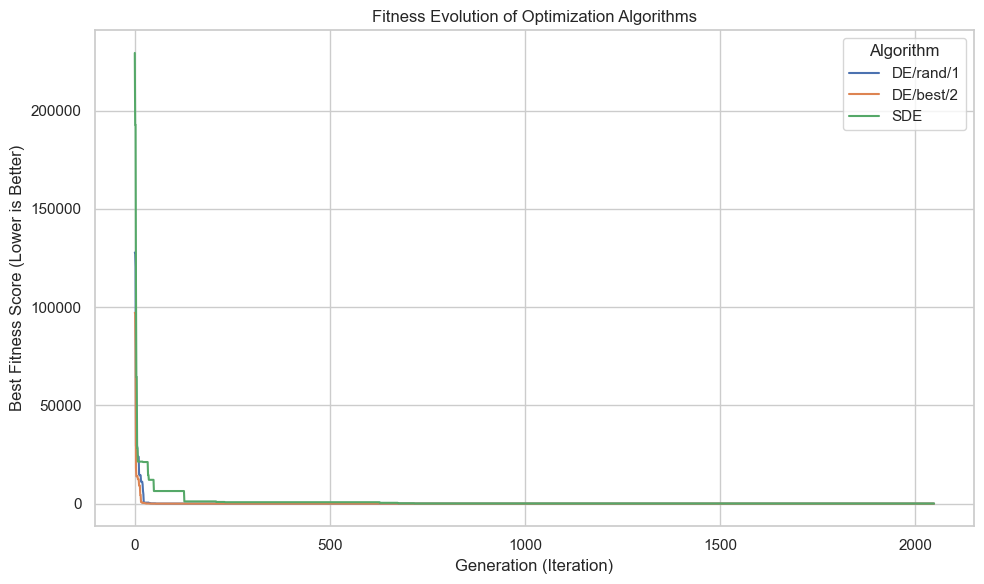

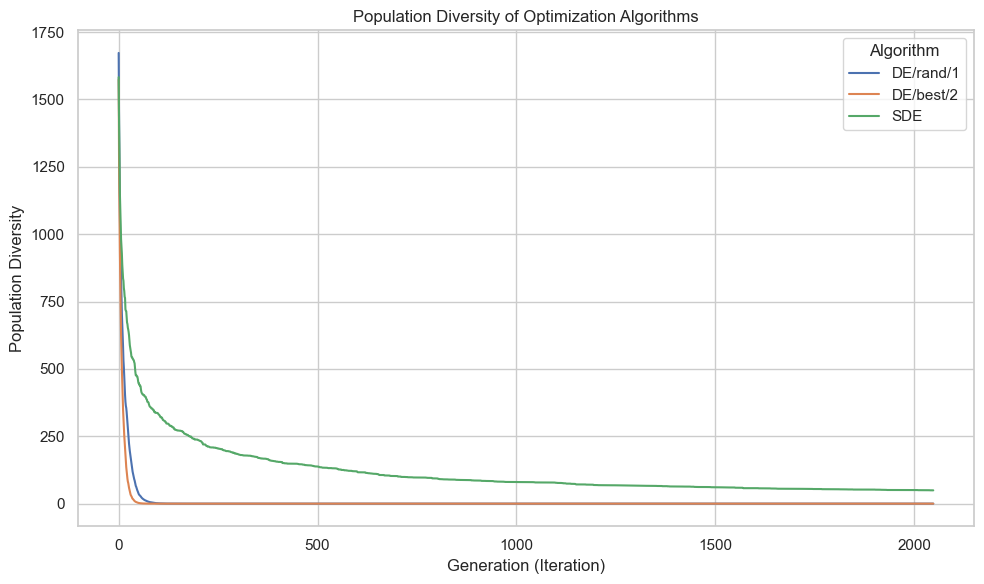

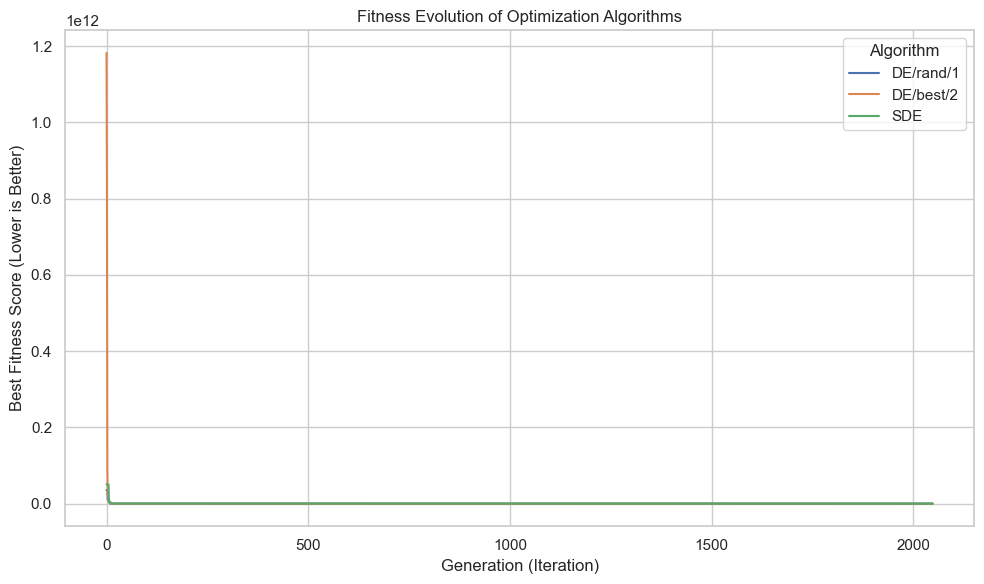

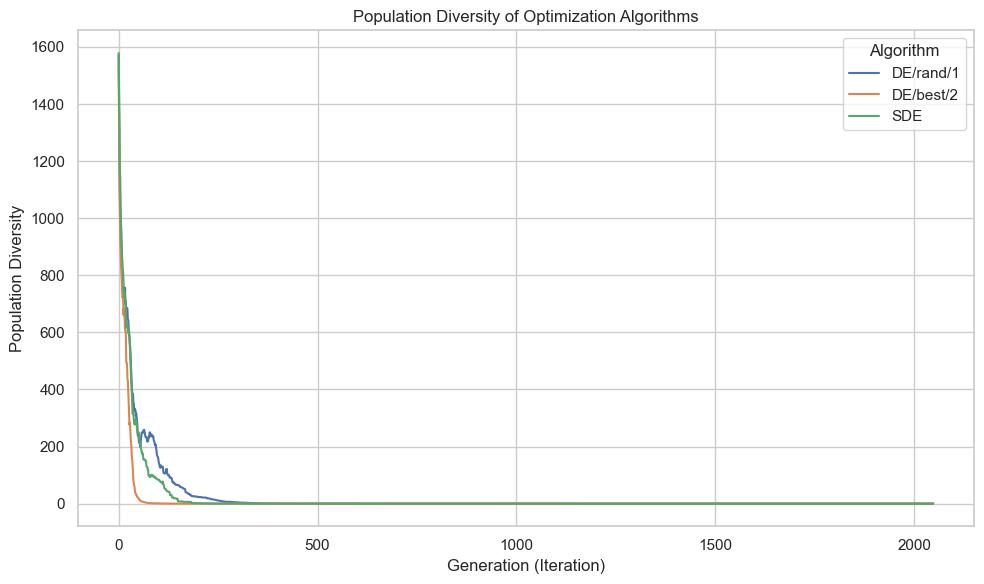

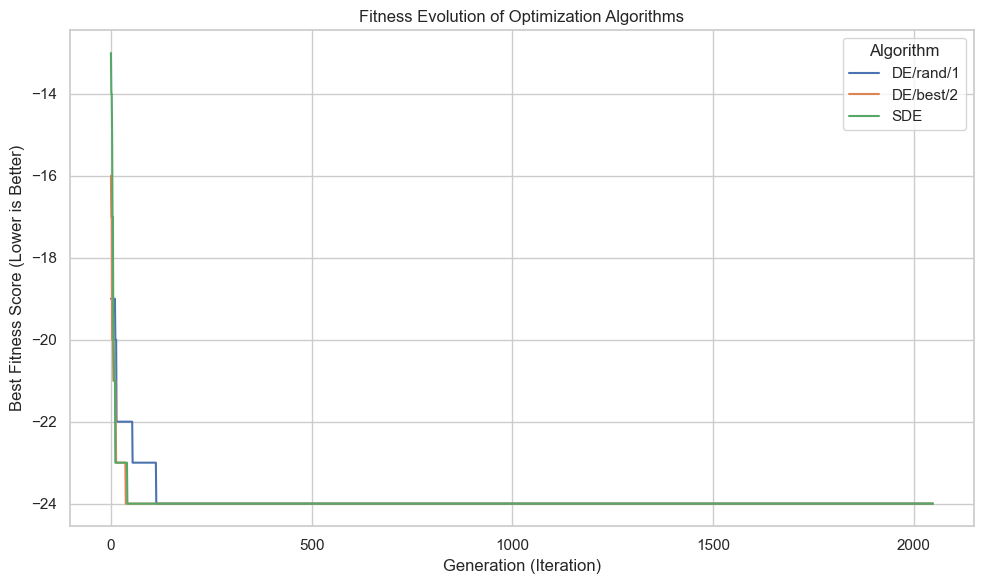

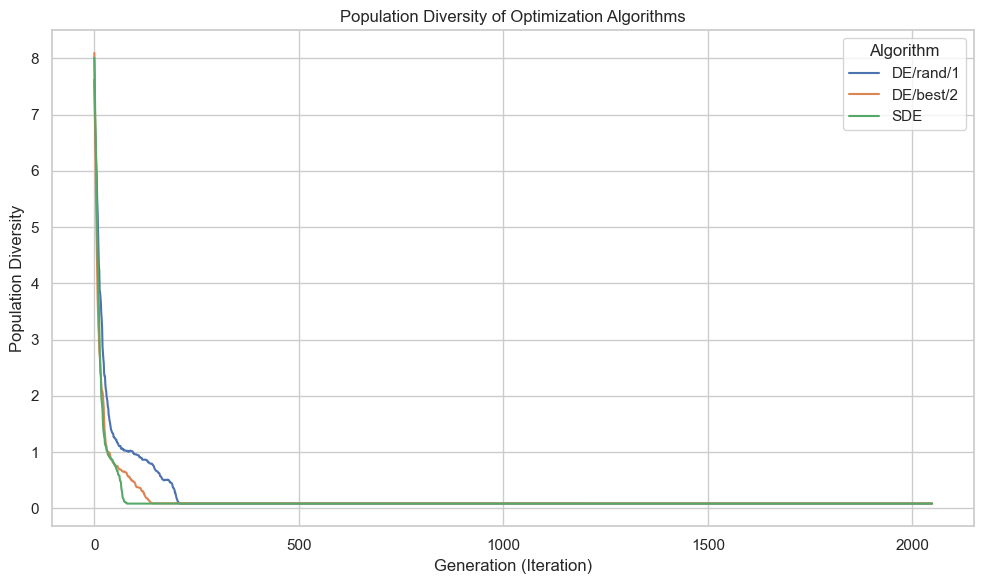

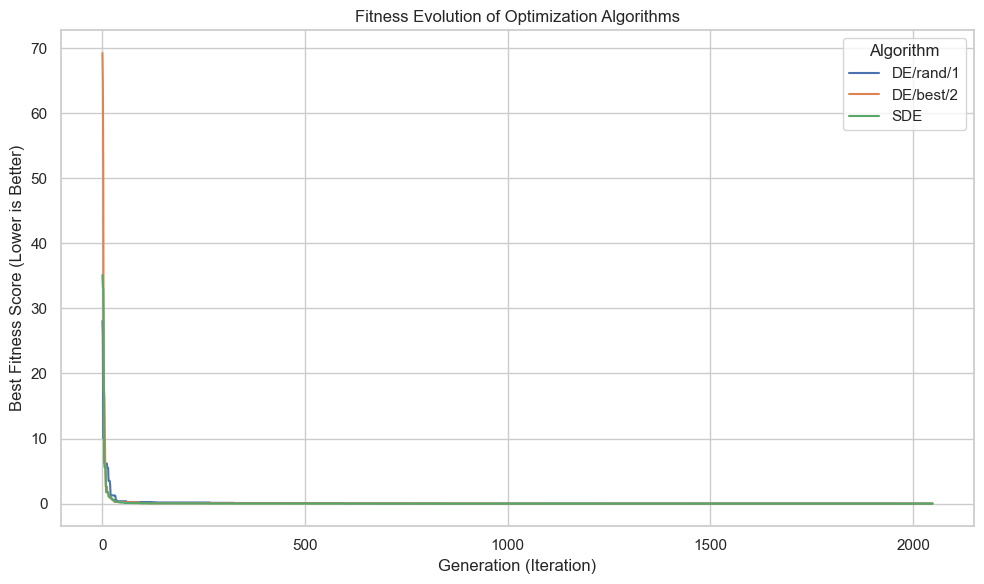

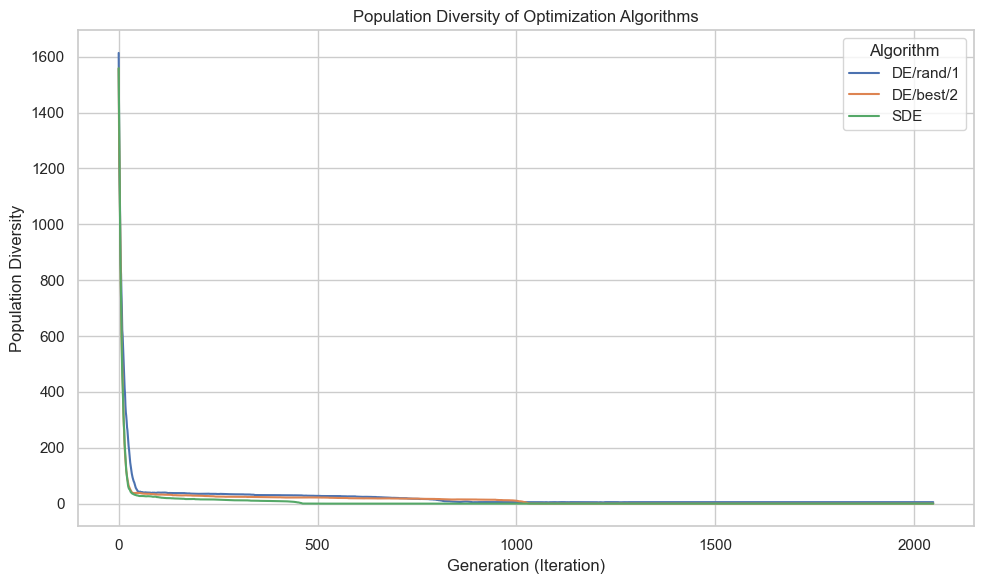

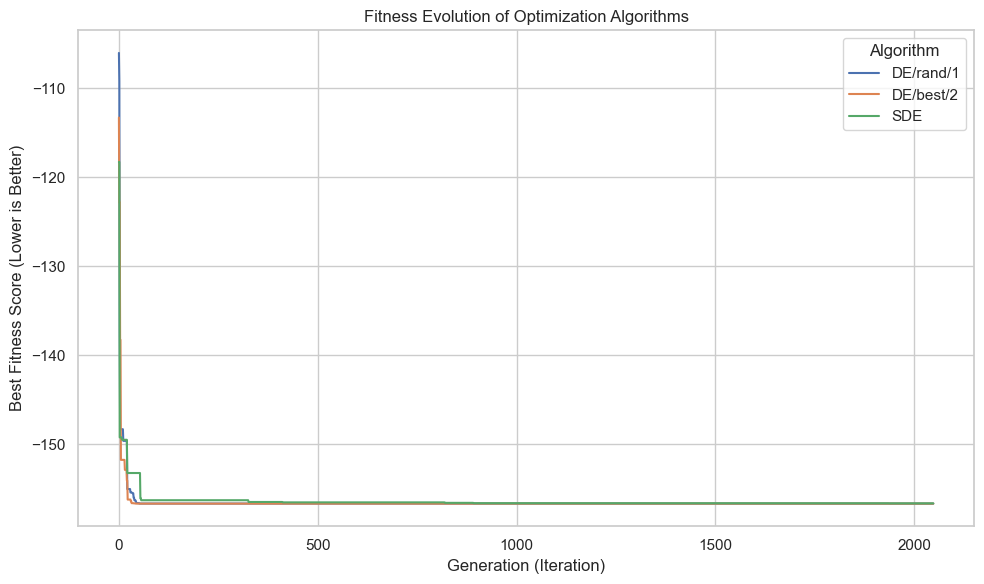

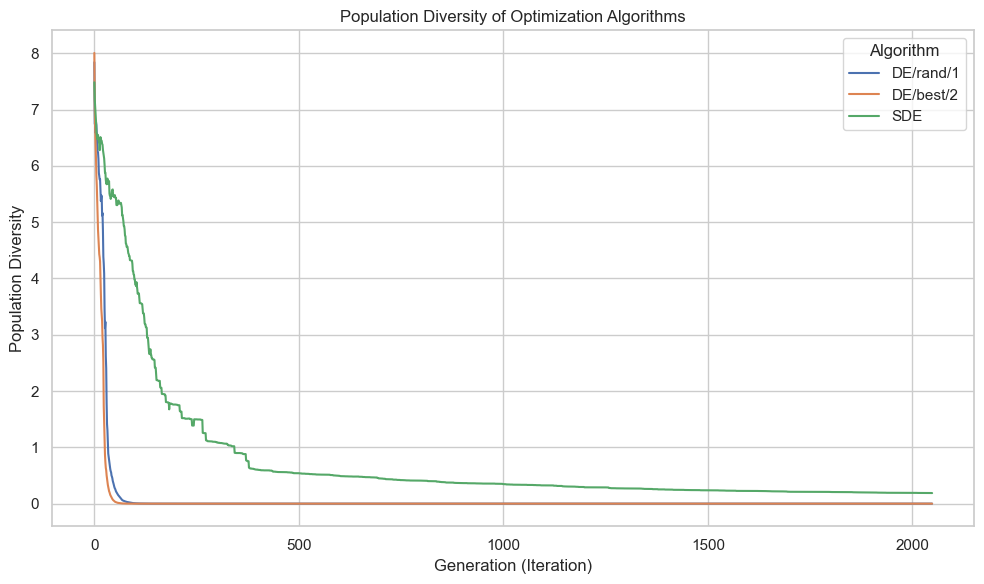

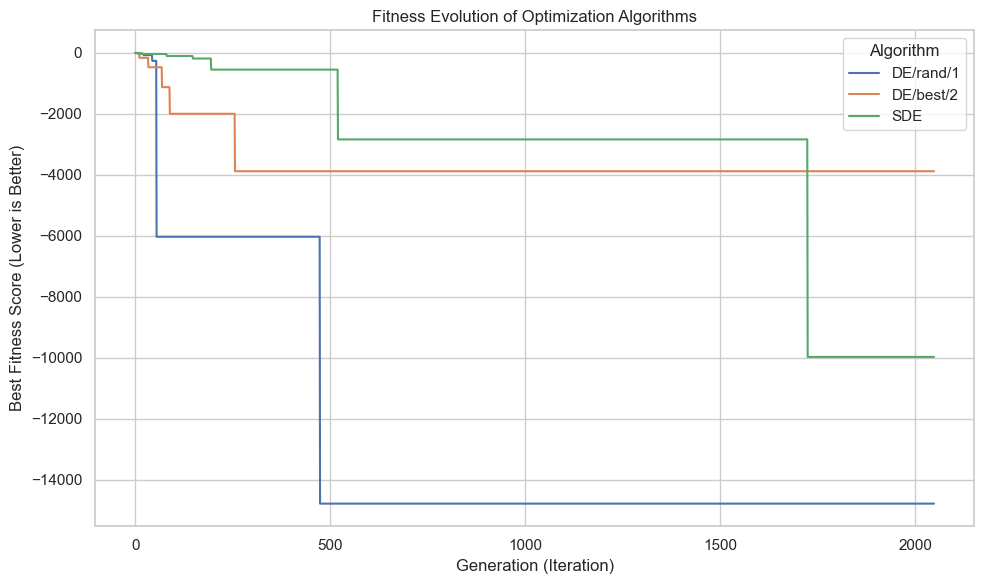

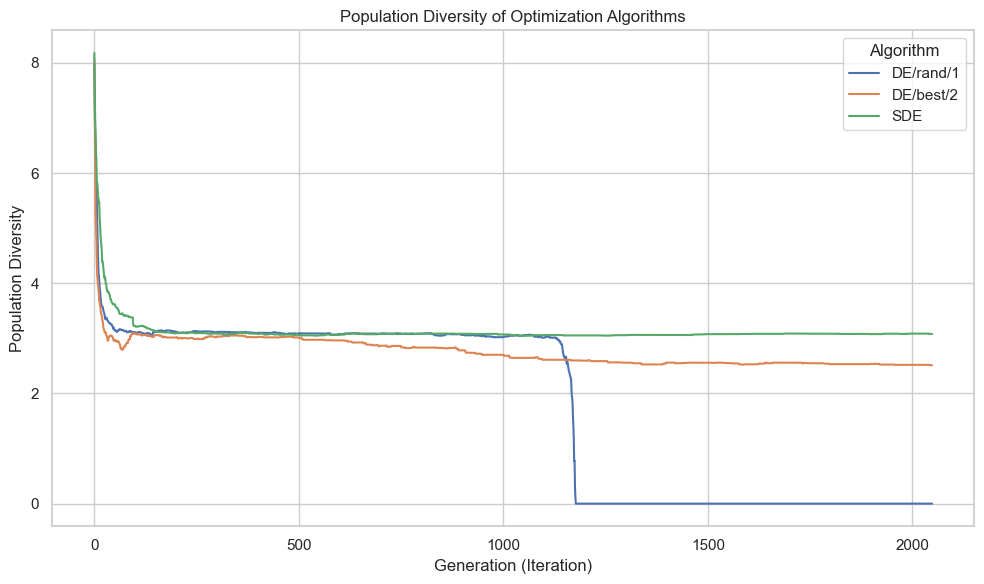

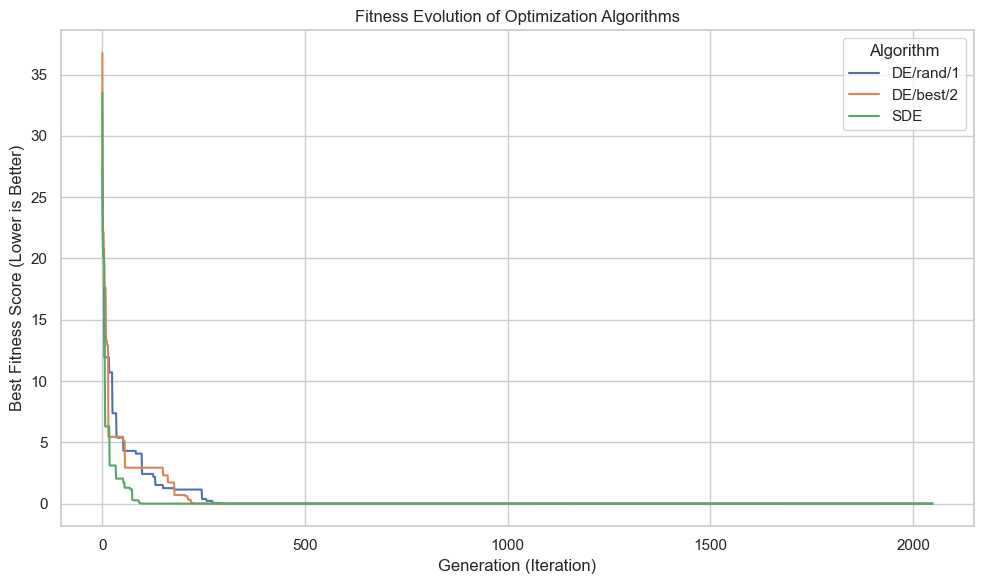

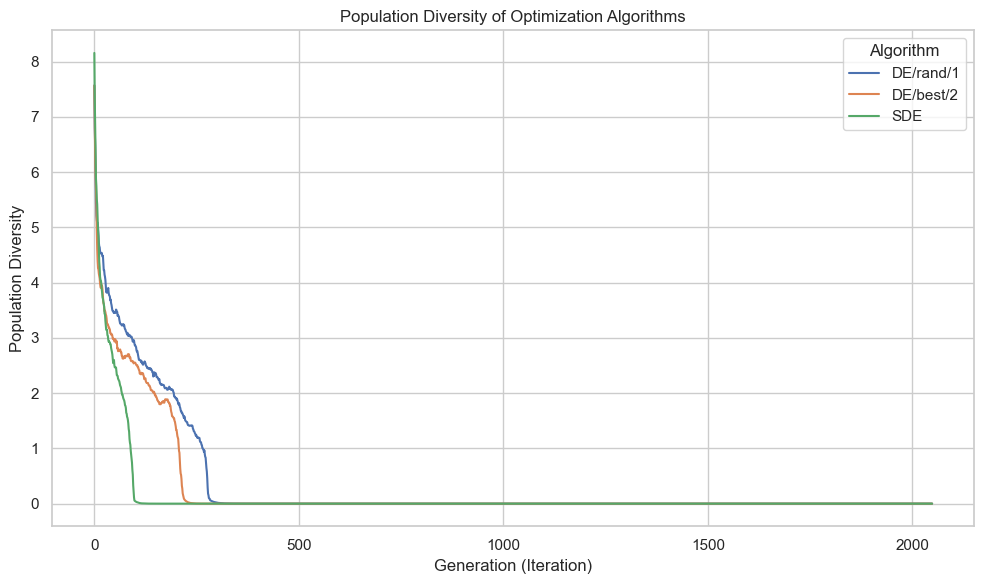

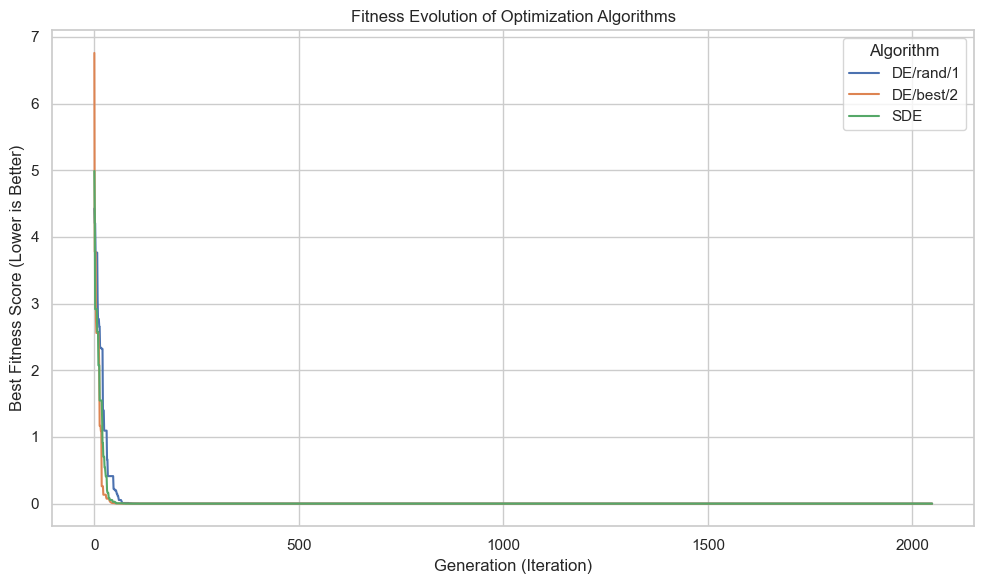

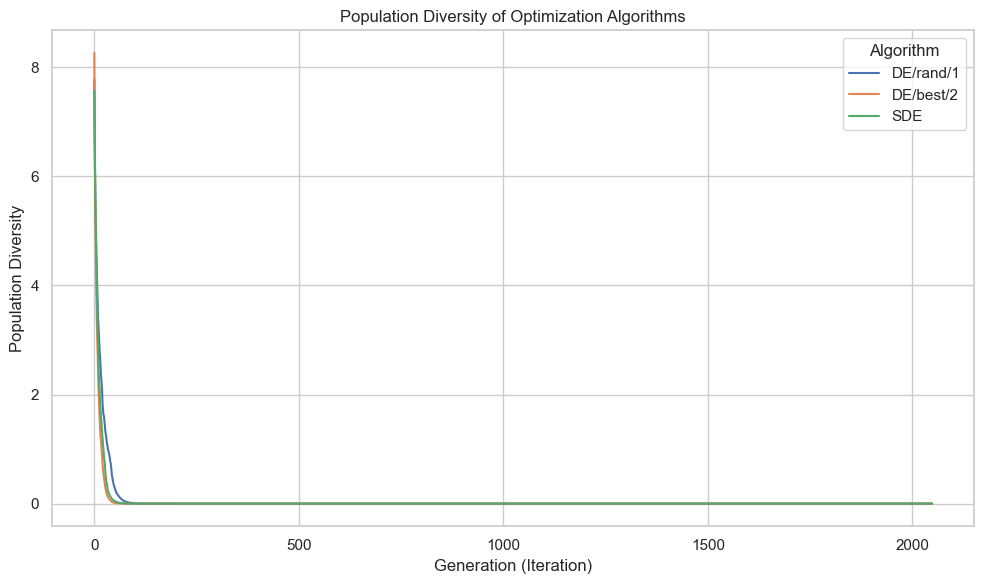

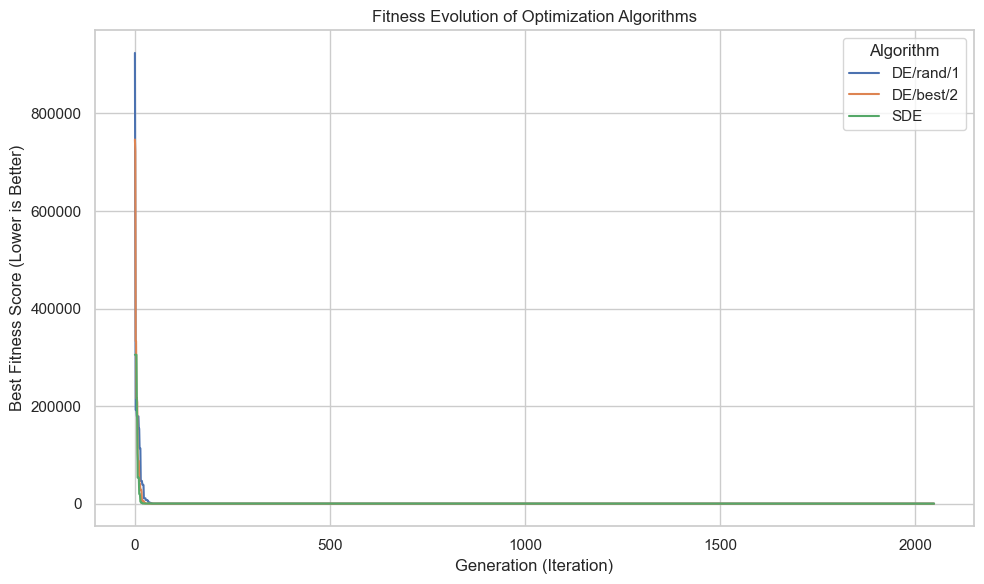

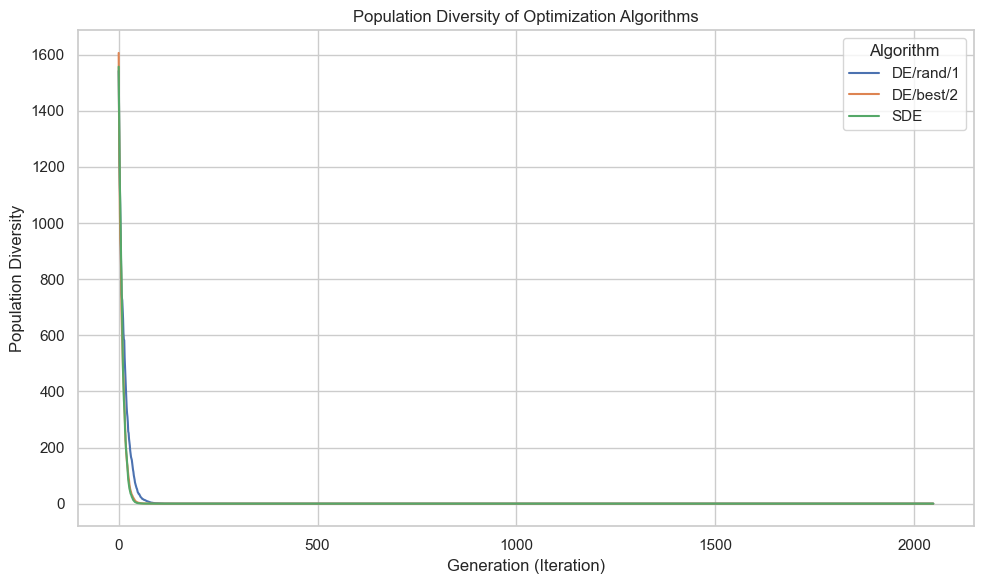

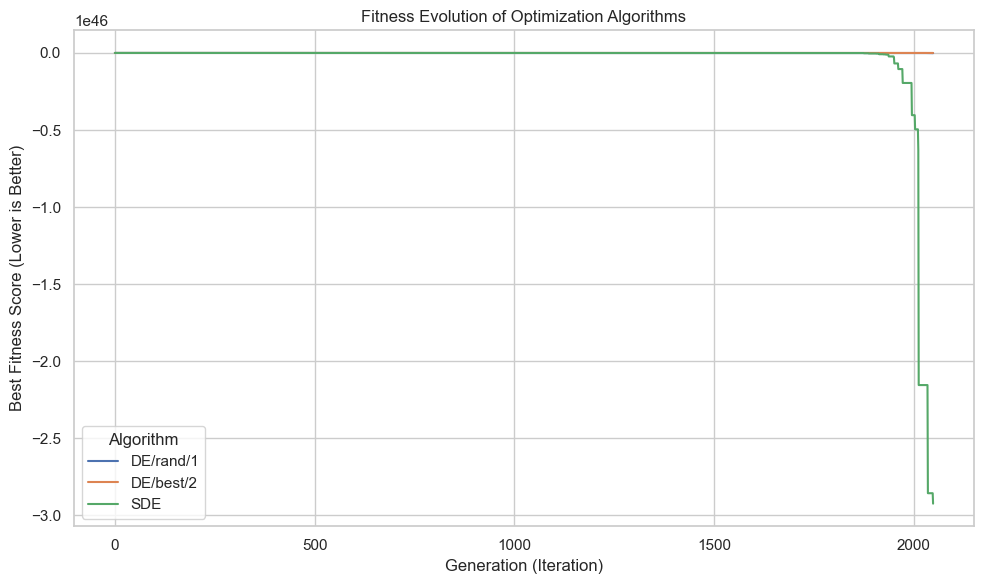

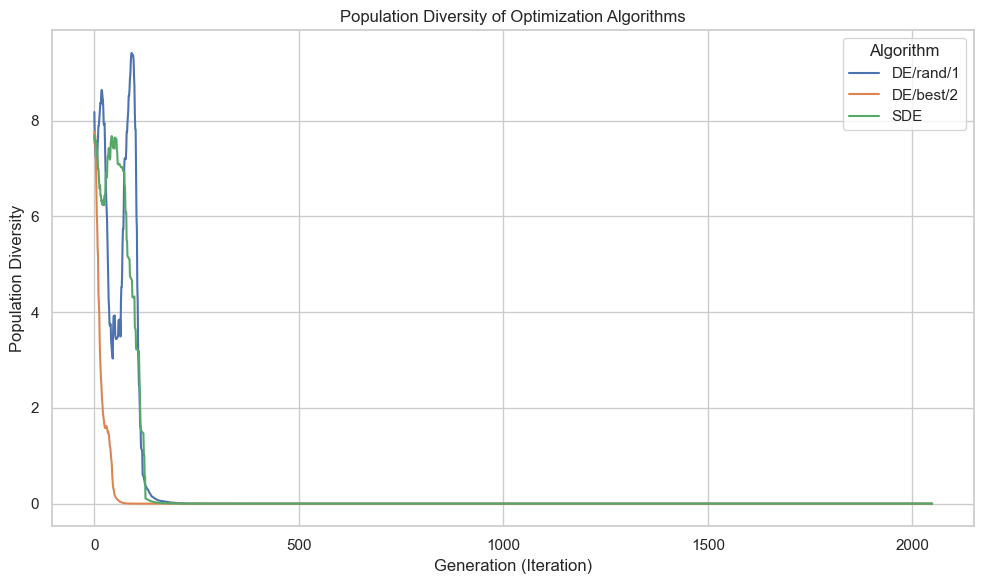

In [25]:
testbed = TestBed()
testbed.run_display()

Comparing with SciPy optimisation

In [26]:
class SciPyTest:
    def __init__(self):
        self.tests = [Sphere, Rosenbrock, Step, Griewank, StyblinskiTang,
                      Shekel, Rastrigin, Ackley, RotatedElipsoid]
        self.results = []
    
    def run(self):
        for test in self.tests:
            x0 = [random.uniform(test.lower_bounds[0], test.upper_bounds[0]) for _ in range(N)]
            self.results.append(minimize(test.fun,
                                         x0,
                                         bounds=zip(test.lower_bounds,
                                                    test.upper_bounds)))
    
    def display_results(self):
        for test, result in zip(self.tests, self.results):
            print(f'for {test.__name__} SciPy found minimum {result.fun} in {result.nit} iter')

In [27]:
refer = SciPyTest()
refer.run()
refer.display_results()

for Sphere SciPy found minimum 1.0011256498919498e-13 in 2 iter
for Rosenbrock SciPy found minimum 2.1908306409776868e-11 in 73 iter
for Step SciPy found minimum -7 in 0 iter
for Griewank SciPy found minimum 74.98059134373364 in 14 iter
for StyblinskiTang SciPy found minimum -100.1177866210488 in 8 iter
for Shekel SciPy found minimum -0.10986443765507144 in 8 iter
for Rastrigin SciPy found minimum 22.88399273065542 in 10 iter
for Ackley SciPy found minimum 5.817678676511921 in 14 iter
for RotatedElipsoid SciPy found minimum 3.1971780296485356e-15 in 10 iter
